In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["customerID"].duplicated().sum()

np.int64(0)

In [19]:
def conv(value):
    if value ==1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"]= df["SeniorCitizen"].apply(conv)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

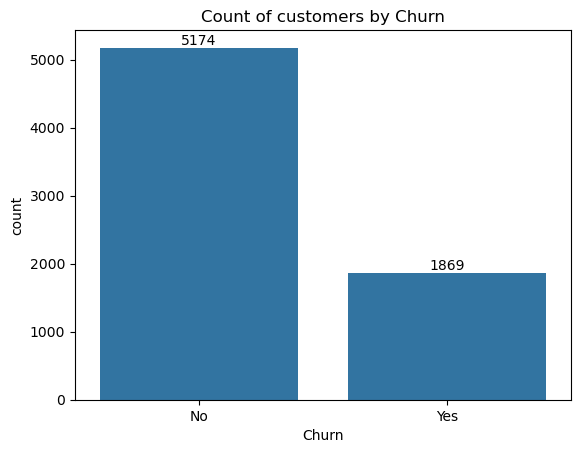

In [28]:
ax= sns.countplot(x='Churn', data=df)

ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

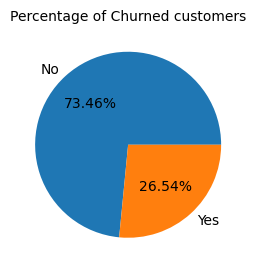

In [30]:
plt.figure(figsize=(3,4))
gb= df.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'], labels=gb.index, autopct="%1.2f%%")
plt.title("Percentage of Churned customers", fontsize=10)
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out. #now lets explore the reason behind it

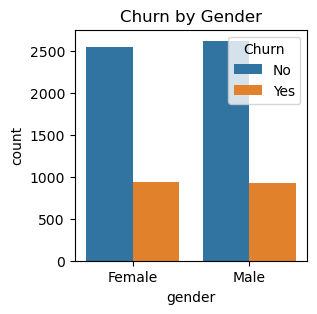

In [35]:
plt.figure(figsize=(3,3))
sns.countplot(x= "gender", data=df, hue="Churn")
plt.title("Churn by Gender")
plt.show()

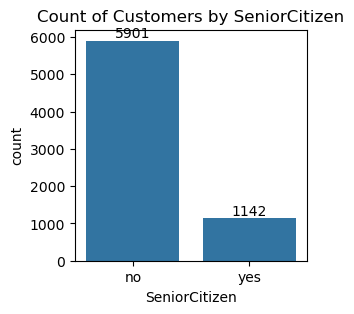

In [40]:
plt.figure(figsize=(3,3)) 
ax= sns.countplot(x= "SeniorCitizen", data=df) 
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen") 
plt.show()

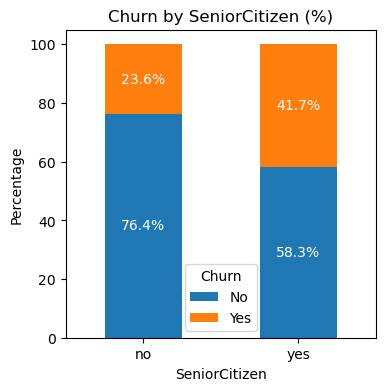

In [41]:
# Create crosstab
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"])

# Convert to percentage
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = ct_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(4,4)
)

# Add percentage labels
for i in range(len(ct_percent)):
    cumulative = 0
    
    for j in range(len(ct_percent.columns)):
        value = ct_percent.iloc[i, j]
        
        ax.text(
            i,                              # x position
            cumulative + value / 2,        # y position
            f"{value:.1f}%",               # label
            ha='center',
            va='center',
            color='white',
            fontsize=10
        )
        
        cumulative += value

plt.title("Churn by SeniorCitizen (%)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show()

#comparatively a greater percentage of people in senior citizen category have churned

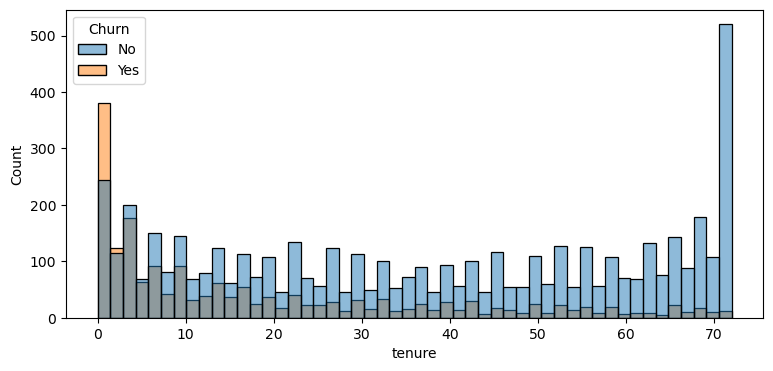

In [43]:
plt.figure(figsize=(9,4)) 
sns.histplot(x="tenure", data=df, bins=50, hue="Churn")
plt.show()

#people who have used our services for a long time have stayed and people who have used our services 1 or 2 months have churned

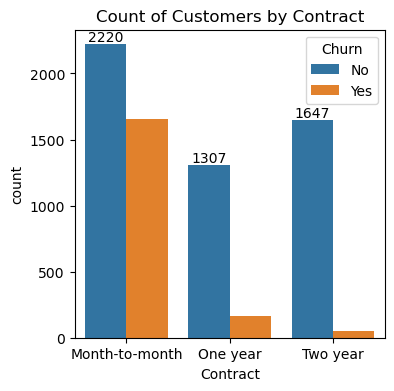

In [45]:
plt.figure(figsize=(4,4)) 
ax= sns.countplot(x= "Contract", data=df, hue ="Churn") 
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract") 
plt.show()

In [ ]:
#people who have month to onth contract are likely to churn then from those who has 1 or 2 years of contract

In [49]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

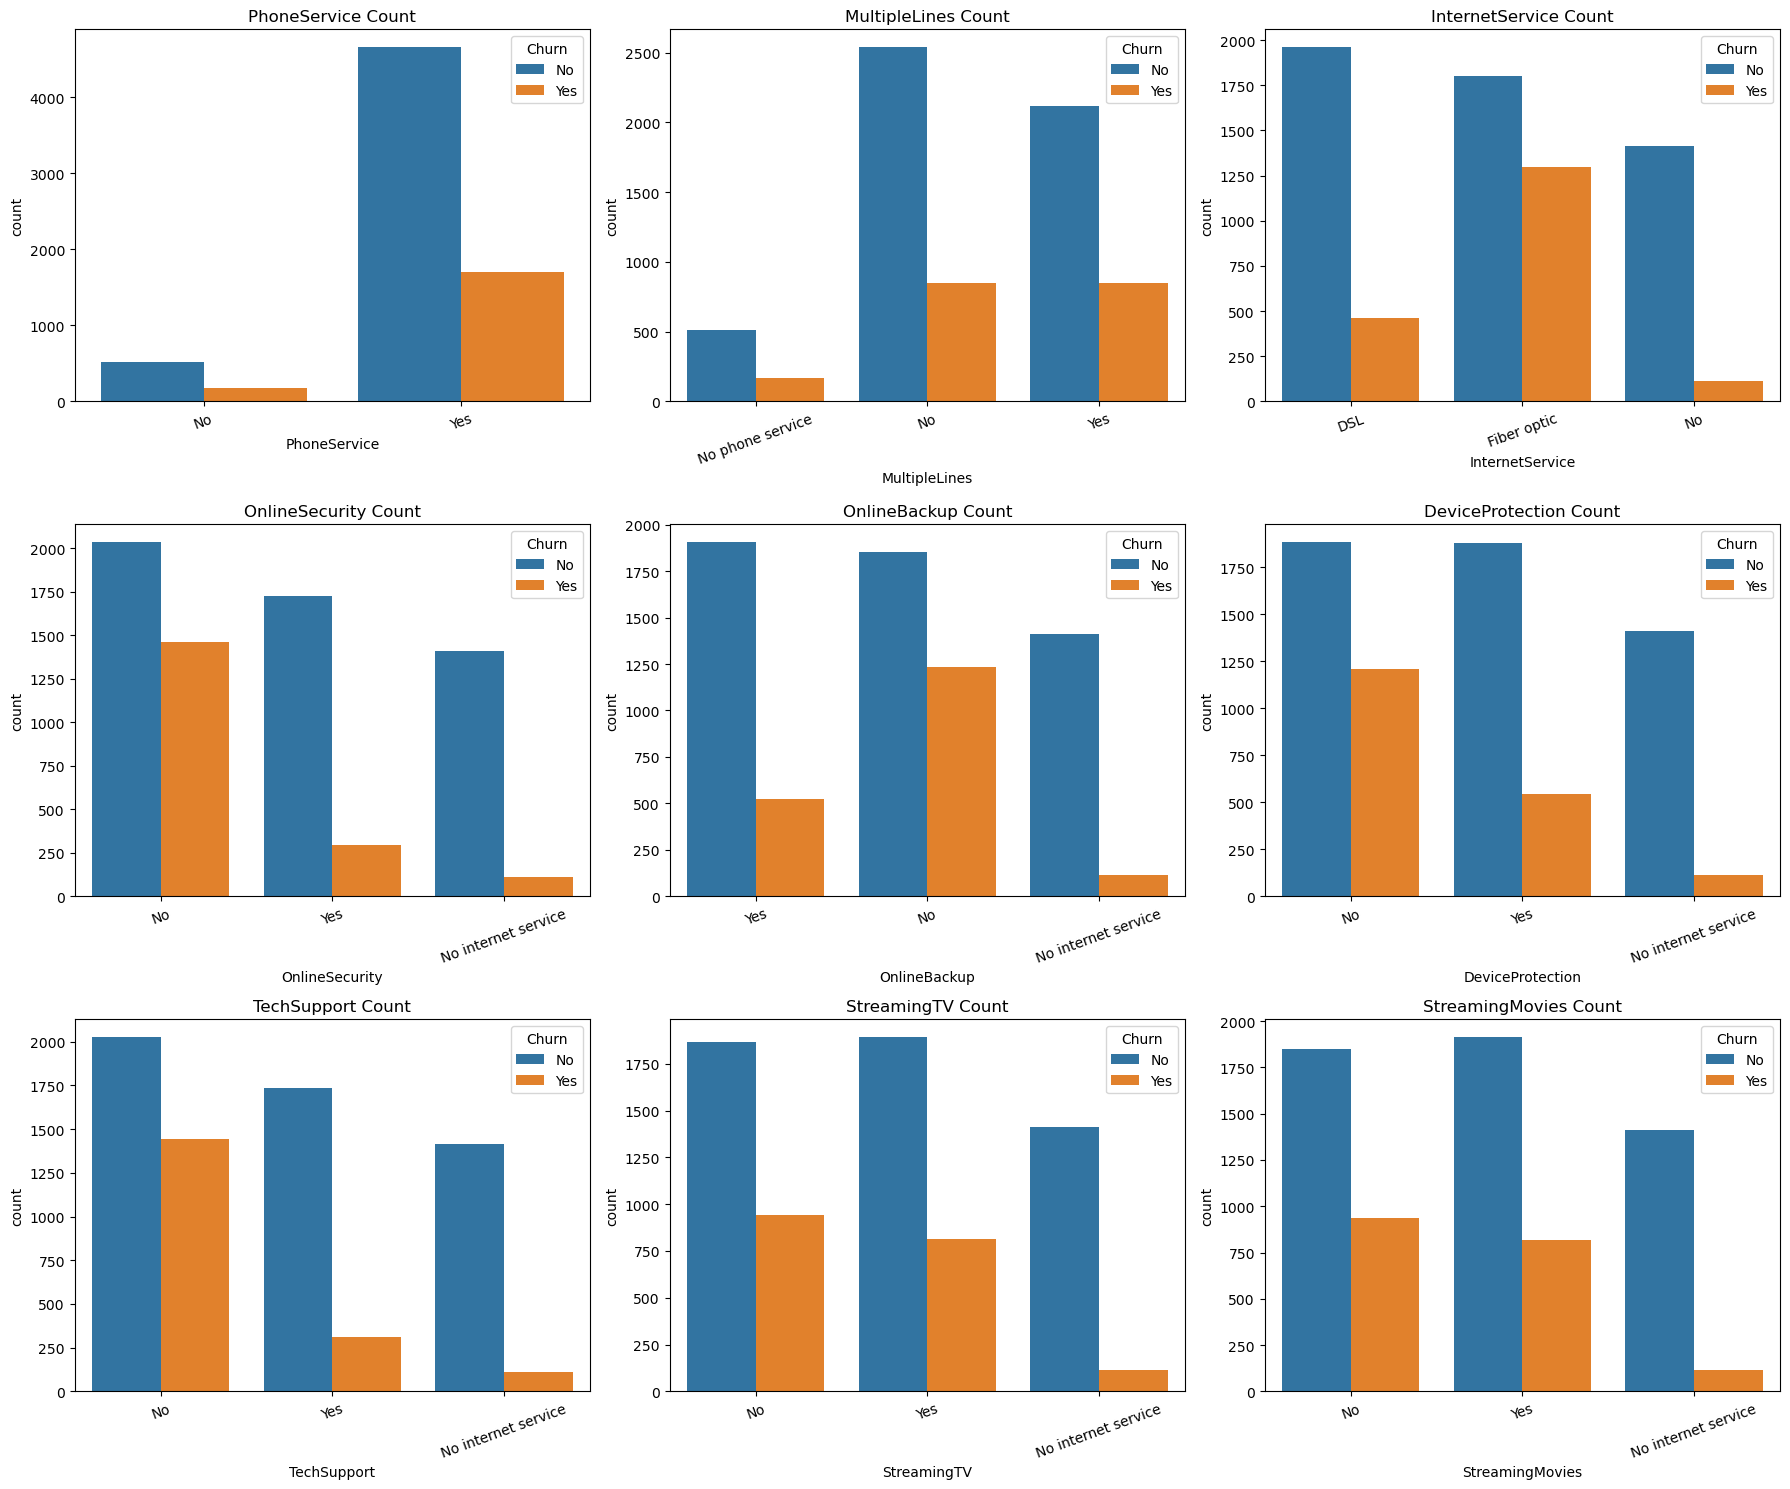

In [51]:


# Columns
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Flatten axes for easy looping
axes = axes.flatten()

# Loop through columns
for i, col in enumerate(cols):
    sns.countplot(
        x=df[col],
        data=df,
        ax=axes[i],
        hue=df["Churn"]
    )
    
    axes[i].set_title(f"{col} Count")
    axes[i].tick_params(axis='x', rotation=20)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

#The majority of customers who do not churn tend to have ervices like PhoneService, InternetService (particularly DSL) and OnlineSecurity enabled. For services like OnlineBackup, TechSupport and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.

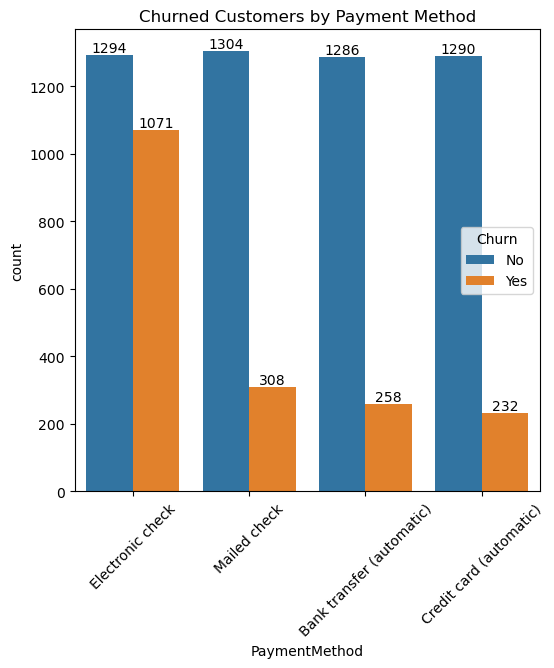

In [57]:
plt.figure(figsize=(6,6)) 
ax= sns.countplot(x= "PaymentMethod", data=df, hue ="Churn") 
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment Method") 
plt.xticks(rotation=45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method